In [1]:
from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt

X,y = make_moons(
    n_samples=300,
    noise = 0.08,
    random_state=42
)

print(X.shape)

(300, 2)


In [2]:
df_dbscan = pd.DataFrame(X,
                         columns=["feature_1","feature_2"])

df_dbscan["target"]=y

df_dbscan.head()

,feature_1,feature_2,target
0,0.658801,-0.355963,1
1,1.986302,-0.133490,1
2,-0.111623,0.455081,1
3,0.905008,0.266798,0
4,1.181619,-0.494965,1


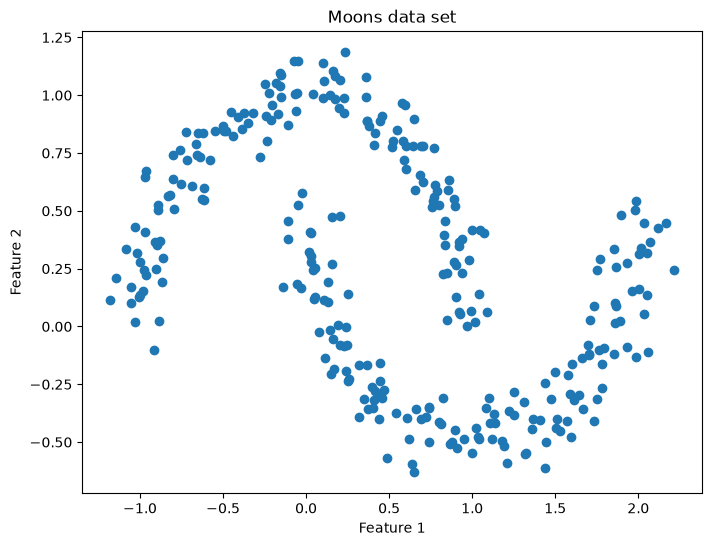

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_dbscan["feature_1"],
    df_dbscan["feature_2"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons data set")

plt.show()


In [4]:
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps = 0.2,
    min_samples=5
)

labels = model.fit_predict(X)

print(labels[:20])

[0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0]


In [5]:
print(pd.Series(labels).value_counts().sort_index())

0    150
1    150
Name: count, dtype: int64


In [6]:
df_dbscan["DBSCAN_cluster"]=labels

df_dbscan.head()

,feature_1,feature_2,target,DBSCAN_cluster
0,0.658801,-0.355963,1,0
1,1.986302,-0.133490,1,0
2,-0.111623,0.455081,1,0
3,0.905008,0.266798,0,1
4,1.181619,-0.494965,1,0


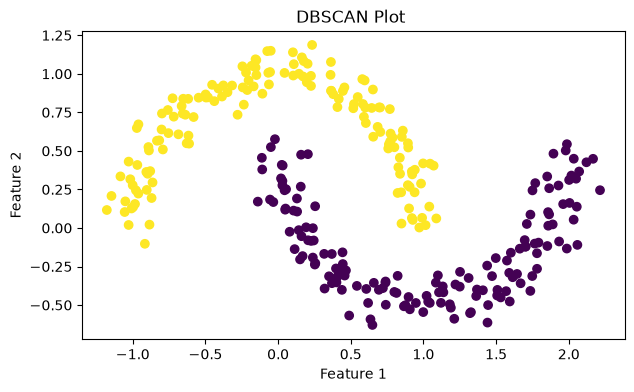

In [7]:
plt.figure(figsize=(7,4))

plt.scatter(
    df_dbscan["feature_1"],
    df_dbscan["feature_2"],
    c=df_dbscan["DBSCAN_cluster"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Plot ")

plt.show()

In [8]:
print("Cluster Sizes:")
print(
    df_dbscan["DBSCAN_cluster"]
    .value_counts()
    .sort_index()
)

Cluster Sizes:
DBSCAN_cluster
0    150
1    150
Name: count, dtype: int64


In [9]:
model.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 179, 180, 181, 18

In [10]:
core_indices = model.core_sample_indices_

print("Number of core points:", len(core_indices))

Number of core points: 295


In [11]:
core_points = X[core_indices]

print(core_points[:10])

[[ 0.65880058 -0.35596254]
 [ 1.98630199 -0.13348998]
 [-0.11162344  0.4550811 ]
 [ 0.90500816  0.26679823]
 [ 1.18161893 -0.49496507]
 [ 1.02169091 -0.44027265]
 [ 0.39841083 -0.26265822]
 [-0.581296    0.71952393]
 [ 0.92036446  0.06419018]
 [ 0.19254572  0.00435812]]


In [13]:
core_indices = set(model.core_sample_indices_)

non_core_indices = [
    i for i in range(len(X))
    if i not in core_indices
]

print("Non-core indices:", non_core_indices)

Non-core indices: [97, 178, 223, 240, 288]
